In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

In [3]:
# Load the 'unsupervised-learning-on-country-data' dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path_country_data = "Country-data.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rohan0301/unsupervised-learning-on-country-data",
  file_path_country_data,
)

print("First 5 records of country_df:")
display(df.head())

/tmp/ipykernel_2066/1215707381.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
First 5 records of country_df:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Project Flow (Ideal Data Science Lifecycle)
### 1. Import Libraries
### 2. Load Dataset
### 3. Understand the Dataset
``` Shape
1. Columns
2. Data Types
3. Missing Values
4. Duplicate Values
5. Statistical Summary
```
### 4. Data Cleaning
``` This dataset is already very clean.

We'll only check

1. Missing Values
2. Duplicate Values
3. Wrong Data Types

No feature engineering is required because this is an unsupervised learning dataset.
```
### 5. Basic EDA
```
Numerical Distribution
Correlation Heatmap
Top 10 Highest Income Countries
GDP Distribution
Child Mortality Distribution
```
### 6. Feature Selection
```
Country name cannot be used.
Explain:
Country is just an identifier.
Machine learns only from numerical values.
```

### 7. Feature Scaling
```
K-Means is distance based.
So scaling is compulsory.
```
### 8. Finding Best K (Elbow Method)
### 9. Train K-Means
### 10. Test K-Means

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.shape


(167, 10)

In [6]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:")
print(df.duplicated().sum())

print("\nData Types:")
df.info()

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Values:
0

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


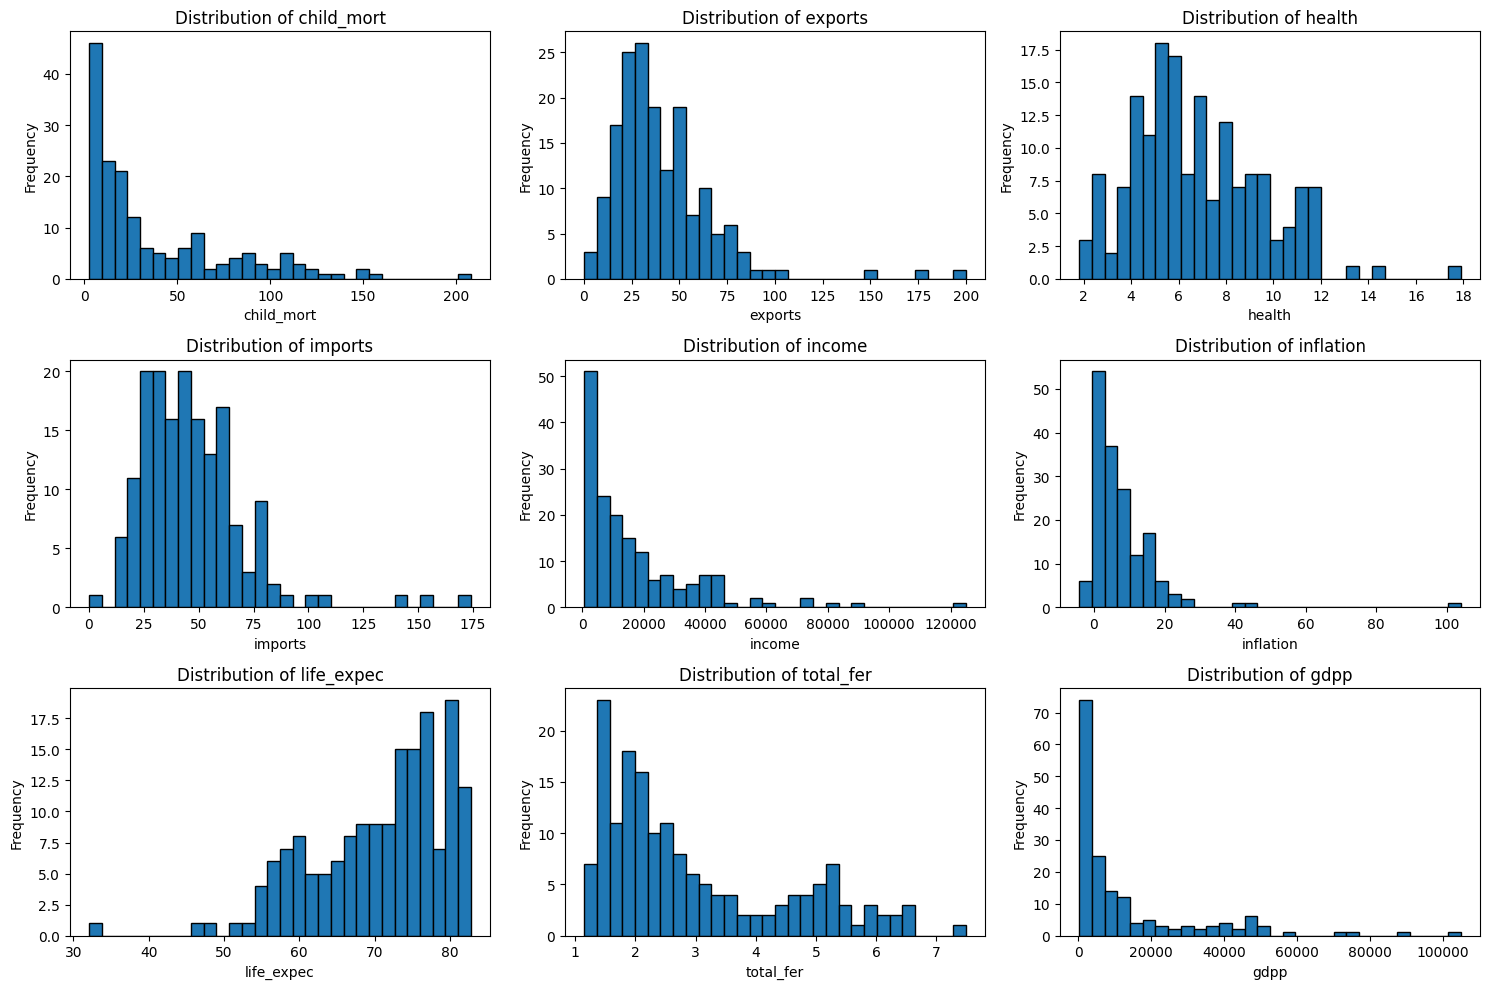

In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed, assuming 9 numerical columns max
    plt.hist(df[col], bins=30, edgecolor='k')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

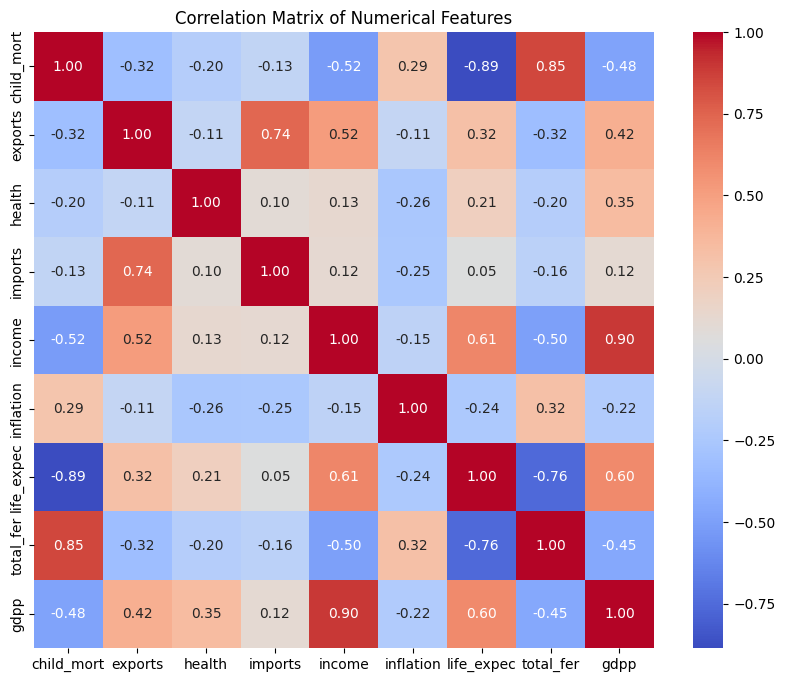

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [9]:
# Part 4 Alredy done

In [10]:
top=df.sort_values("income")
top10=top.head(10)
top10

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.80,57.5,6.54,334
88,Liberia,89.3,19.10,11.80,92.6,700,5.47,60.8,5.02,327
26,Burundi,93.6,8.92,11.60,39.2,764,12.30,57.7,6.26,231
112,Niger,123.0,22.20,5.16,49.1,814,2.55,58.8,7.49,348
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.01,47.5,5.21,446
106,Mozambique,101.0,31.50,5.21,46.2,918,7.64,54.5,5.56,419
94,Malawi,90.5,22.80,6.59,34.9,1030,12.10,53.1,5.31,459
63,Guinea,109.0,30.30,4.93,43.2,1190,16.10,58.0,5.34,648
150,Togo,90.3,40.20,7.65,57.3,1210,1.18,58.7,4.87,488
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.20,55.0,5.20,399


In [11]:
top

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334
88,Liberia,89.3,19.10,11.80,92.6,700,5.470,60.8,5.02,327
26,Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231
112,Niger,123.0,22.20,5.16,49.1,814,2.550,58.8,7.49,348
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.010,47.5,5.21,446
...,...,...,...,...,...,...,...,...,...,...
133,Singapore,2.8,200.00,3.96,174.0,72100,-0.046,82.7,1.15,46600
82,Kuwait,10.8,66.70,2.63,30.4,75200,11.200,78.2,2.21,38500
23,Brunei,10.5,67.40,2.84,28.0,80600,16.700,77.1,1.84,35300
91,Luxembourg,2.8,175.00,7.77,142.0,91700,3.620,81.3,1.63,105000


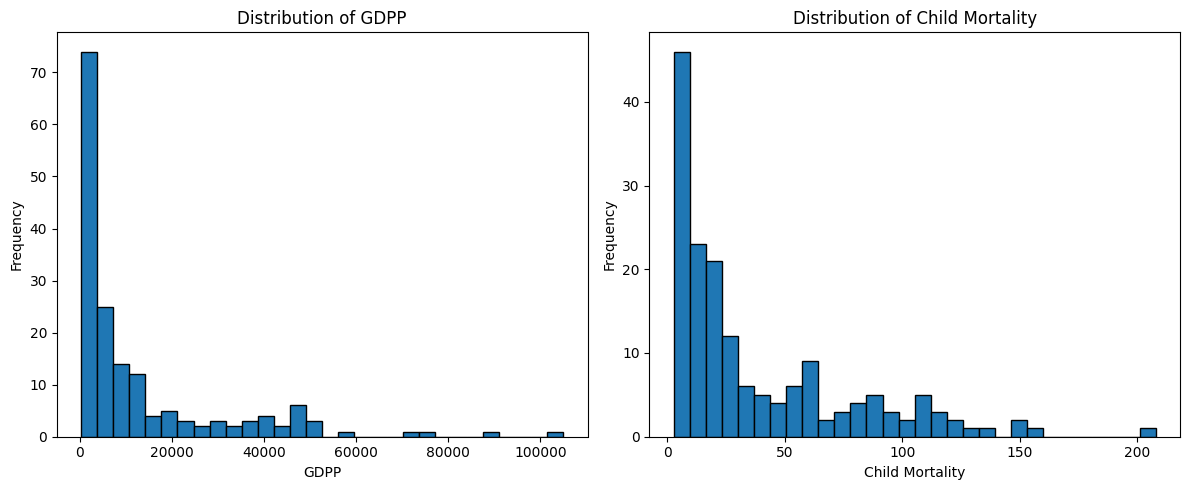

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['gdpp'], bins=30, edgecolor='k')
plt.title('Distribution of GDPP')
plt.xlabel('GDPP')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['child_mort'], bins=30, edgecolor='k')
plt.title('Distribution of Child Mortality')
plt.xlabel('Child Mortality')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [13]:
# Feature Selection: Removing the 'country' column
df_features = df.drop(columns=['country'])
df_features

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [14]:
from sklearn.preprocessing import StandardScaler

# Define X using the features selected previously
X = df_features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the scaled data (now a numpy array)
X_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

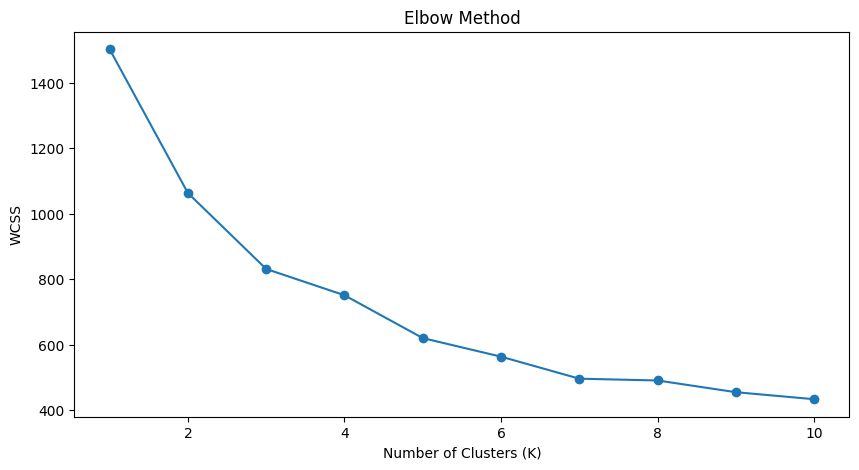

In [15]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [16]:
# Training K-Means with K=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_kmeans

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


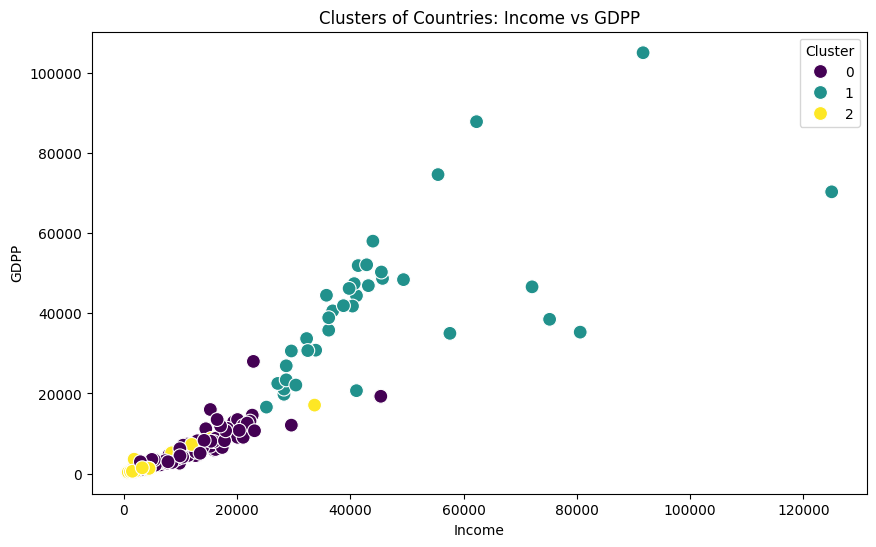

Mean values for each cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the clusters based on Income and GDPP
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='income', y='gdpp', hue='Cluster', palette='viridis', s=100)
plt.title('Clusters of Countries: Income vs GDPP')
plt.xlabel('Income')
plt.ylabel('GDPP')
plt.legend(title='Cluster')
plt.show()

# Group by Cluster to see the mean values of each feature to help interpret the clusters
cluster_profile = df.drop(columns=['country']).groupby('Cluster').mean()
print("Mean values for each cluster:")
display(cluster_profile)

In [18]:
import joblib
joblib.dump(kmeans, 'kmeans_model.joblib')

['kmeans_model.joblib']